# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

# План работы
**Цель:** создать модель для прогнозирования оттока клиентов для сервиса доставки кофе

**Задачи:**
- Проанализировать данные
- Предобработать данные, создав пайпланый и трансформер
- Обучить базовую модель
- Создать новые признаки
- Подобрать гиперпараметры
- Обучить финальную модель
- Сохранить финальную модель

**Описание данных**

*Целевая переменная: churn — перестал ли пользователь пользоваться сервисом.*

*Признаки:*
- user_id — идентификатор пользователя.
- days_since_last_order — количество дней, прошедших с последнего заказа.
- order_frequency_month — среднее число заказов в месяц.
- order_frequency_week — среднее число заказов в неделю.
- avg_order_value — средний чек, в рублях.
- median_order_value — медианный чек, в рублях.
- total_spent_last_month — сумма заказов за последний месяц.
- total_spent_last_week — сумма заказов за последнюю неделю.
- discount_usage_rate — доля заказов со скидкой за последний месяц.
- last_coffee_type — сорт кофе, купленный пользователем в последний раз на момент сбора данных.
- preferred_roast — предпочитаемый тип обжарки.
- milk_preference — предпочитаемый тип молока.
- seasonal_menu_tried — отметка о том, пробовал ли пользователь новейшее сезонное меню.
- coffee_bean_origin — страна происхождения зерна.
- last_drink_size — размер последнего заказа, совершённого на момент сбора данных.
- subscription_status — тип подписки пользователя.
- app_opens_per_week — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе.
- notifications_enabled — включены ли у пользователя уведомления.
- review_rating_last_10 — средняя оценка последних на момент сбора данных десяти заказов клиента.
- review_rating_last_1 — оценка последнего на момент сбора данных заказа клиента.
- app_crashes_last_month — сколько раз приложение зависало за последний месяц.
- seasons — текущее время года.
- days_since_last_promo — сколько дней прошло с последнего использования акции или промокода.
- phone_type — тип устройства, с которого пользователь чаще всего совершал покупки.
- coffee_preference_change — менялись ли вкусовые предпочтения пользователя.
- geo_id — идентификатор региона пользователя.

## Этап 1. Подготовка среды и библиотек

In [1]:
pip install phik

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install --upgrade scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 13.8 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.0 MB 24.1 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 22.8 MB/s  0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2


  You can safely remove it manually.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install joblib 


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from phik import phik_matrix
import joblib

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, average_precision_score, precision_score, recall_score


In [5]:
RANDOM_STATE = 45
df = pd.read_csv('C:/Users/OC/Downloads/datasets/coffee_churn_dataset.csv', decimal='.')
df.head(5)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


## Этап 2. Первичный анализ данных

Проанализируем датасет

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

Датасет состоит из 10450 строк и 27 столбцов. Во многих столбцах присутствуеют пропуски, которые нужно будет обработать, а также некоторые данные представлены типом данных `object`, их будет необходимо закодировать


Целевой переменной будет столбец churn, в данном столбце нет пропусков. Проверим распределение целевой переменной с помощью столбчатой диаграммы




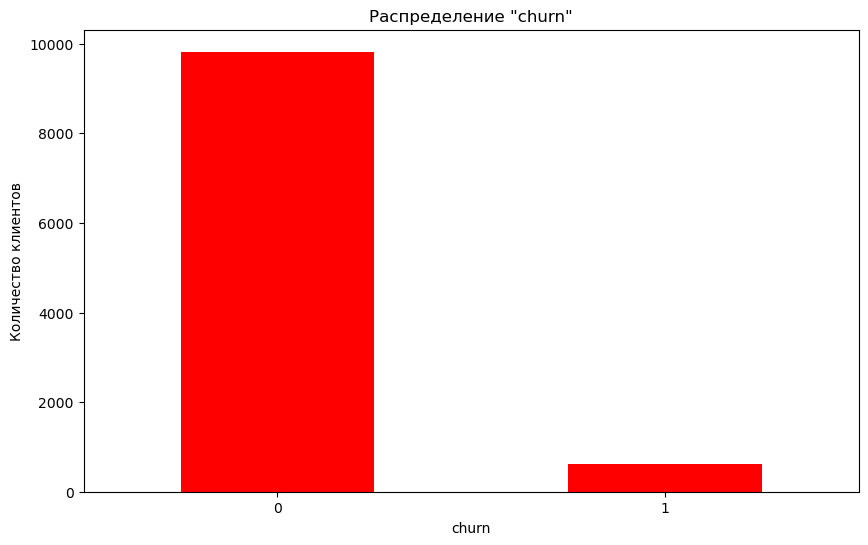

In [7]:
churn_count = df.groupby('churn')['user_id'].count().sort_values(ascending=False)
plt.figure(figsize=(10,6))
churn_count.plot(kind='bar', title='Распределение "churn"', ylabel='Количество клиентов', color='red')
plt.xticks(rotation=360)
plt.show()

Можно заметить, что в целевой переменной преобладает класс клиентов, которые продолжают пользоваться услугами кофейни

Построим корреляции и тепловую карту, чтобы посмотреть, как признаки влияют на целевую переменную


In [8]:
cat_col = []
continuous_cols = []
for i in df.columns:
    if df[i].dtype == 'object':
        cat_col.append(i)
    else:
        continuous_cols.append(i)
df_subset = df[cat_col + continuous_cols]
corr_matrix = phik_matrix(df_subset, continuous_cols)
churn_correlations = corr_matrix.loc['churn']
churn_correlations


C:\Users\OC\anaconda3\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable user_id is large: 10450. Are you sure this is not an interval variable? Analysis for pairs of variables including user_id can be slow.
  warnings.warn(


user_id                     1.000000
last_coffee_type            0.004434
preferred_roast             0.000000
milk_preference             0.000000
coffee_bean_origin          0.000000
last_drink_size             0.000000
subscription_status         0.105164
seasons                     0.000000
phone_type                  0.005039
geo_location                0.038881
days_since_last_order       0.000000
order_frequency_month       0.079332
order_frequency_week        0.080252
avg_order_value             0.032515
median_order_value          0.000000
total_spent_last_month      0.033998
total_spent_last_week       0.064183
discount_usage_rate         0.028110
seasonal_menu_tried         0.000000
app_opens_per_week          0.126117
notifications_enabled       0.000000
review_rating_last_10       0.033943
review_rating_last_1        0.002342
app_crashes_last_month      0.853545
days_since_last_promo       0.000000
coffee_preference_change    0.000000
churn                       1.000000
N

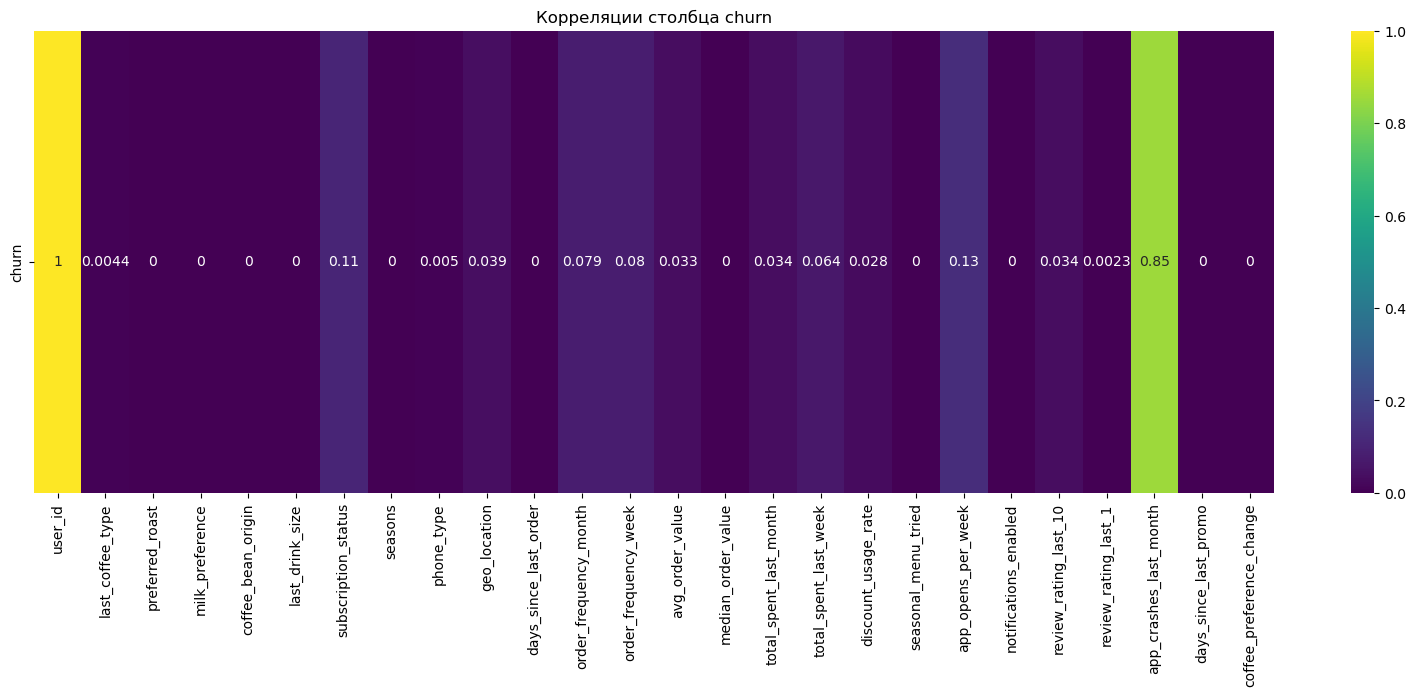

In [9]:
corr_churn = corr_matrix.loc[['churn'], corr_matrix.columns != 'churn']
plt.figure(figsize=(20,6))
sns.heatmap(corr_churn, annot=True, cmap='viridis') 
plt.title('Корреляции столбца churn') 
plt.show()

Можно заметить, что у `churn` нулевая корреляция со следующими признаками: `preferred_roast, milk_preference, coffee_bean_origin, last_drink_size, seasons, days_since_last_order, seasonal_menu_tried, notifications_enabled, days_since_last_promo, coffee_preference_change`. Так же стоит удалить столбцы `order_frequency_month, total_spent_last_month, review_rating_last_1, median_order_value`, так как есть столбцы с практически идентичными признаками, которые более релевантны (нет смысла сохранять статистику за месяц, так как данные представлены за один месяц - намного полезнее будет смотреть по неделям), их сохранение может привести к мультиколлинеарности. Так же удалим `user_id`



In [10]:
df_new = df.drop(columns=['user_id', 'order_frequency_month', 'total_spent_last_month', 'review_rating_last_1', 'median_order_value'])
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     9505 non-null   float64
 1   order_frequency_week      10062 non-null  float64
 2   avg_order_value           9867 non-null   float64
 3   total_spent_last_week     9506 non-null   float64
 4   discount_usage_rate       10053 non-null  float64
 5   last_coffee_type          10192 non-null  object 
 6   preferred_roast           10334 non-null  object 
 7   milk_preference           9782 non-null   object 
 8   seasonal_menu_tried       9461 non-null   float64
 9   coffee_bean_origin        9768 non-null   object 
 10  last_drink_size           9946 non-null   object 
 11  subscription_status       9512 non-null   object 
 12  app_opens_per_week        9554 non-null   float64
 13  notifications_enabled     9913 non-null   float64
 14  review

Проанализируем пропуски в данных

In [11]:
null_per = df_new.isnull().mean().sort_values(ascending=False)
null_per

seasonal_menu_tried         0.094641
days_since_last_order       0.090431
total_spent_last_week       0.090335
subscription_status         0.089761
app_opens_per_week          0.085742
days_since_last_promo       0.069952
app_crashes_last_month      0.068995
review_rating_last_10       0.066316
coffee_bean_origin          0.065263
seasons                     0.064976
milk_preference             0.063923
coffee_preference_change    0.058373
avg_order_value             0.055789
notifications_enabled       0.051388
last_drink_size             0.048230
discount_usage_rate         0.037990
order_frequency_week        0.037129
phone_type                  0.032153
last_coffee_type            0.024689
preferred_roast             0.011100
geo_location                0.010526
churn                       0.000000
dtype: float64

- В столбцах `app_opens_per_week`, `app_crashes_last_month`, `order_frequency_week`, `discount_usage_rate`, `total_spent_last_week`, `days_since_last_promo`, `days_since_last_order`, `seasonal_menu_tried`,  `notifications_enabled`, `coffee_preference_change` пропуски можно заменить на 0

- В столбцах `geo_location`, `last_coffee_type`, `phone_type`, `preferred_roast` пропуски стоит удалить, так как их процент невелик(1-2%), а заменить их сложно, не испортив логику данных

- В столбцах `avg_order_value`, `review_rating_last_10`, `coffee_bean_origin`, `last_drink_size`  пропуски можно заменить средним или медианой

- В столбце `subscription_status`, `milk_preference`, `seasons`  пропуски можно заменить на категорию none

В датасете остались категориальные данные - `geo_location, phone_type, subscription_status, last_coffee_type, coffee_bean_origin, seasons, milk_preference, last_drink_size, preferred_roast, seasonal_menu_tried, notifications_enabled, coffee_preference_change`. Их необходимо закодировать, чтобы модель корректно работала, так как она учится на числовых данных. Посмотрим на распределение этих данных

In [12]:
coffee_preference_change = df_new['coffee_preference_change'].value_counts().sort_values(ascending=False)
coffee_preference_change

coffee_preference_change
0.0    7946
1.0    1894
Name: count, dtype: int64

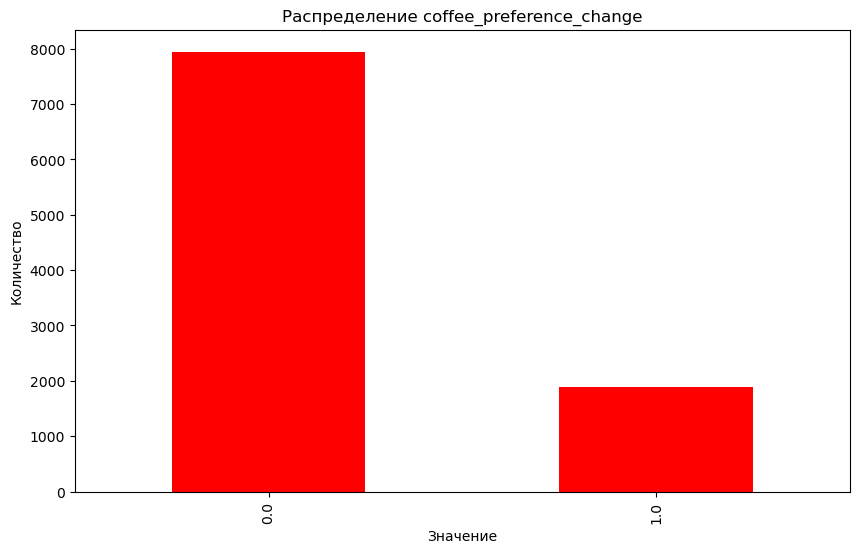

In [13]:
df_new['coffee_preference_change'].value_counts().plot(kind='bar', figsize=(10,6), color='red') 
plt.title('Распределение coffee_preference_change') 
plt.xlabel('Значение') 
plt.ylabel('Количество') 
plt.show()

In [14]:
notifications_enabled = df_new['notifications_enabled'].value_counts().sort_values(ascending=False)
notifications_enabled

notifications_enabled
1.0    7465
0.0    2448
Name: count, dtype: int64

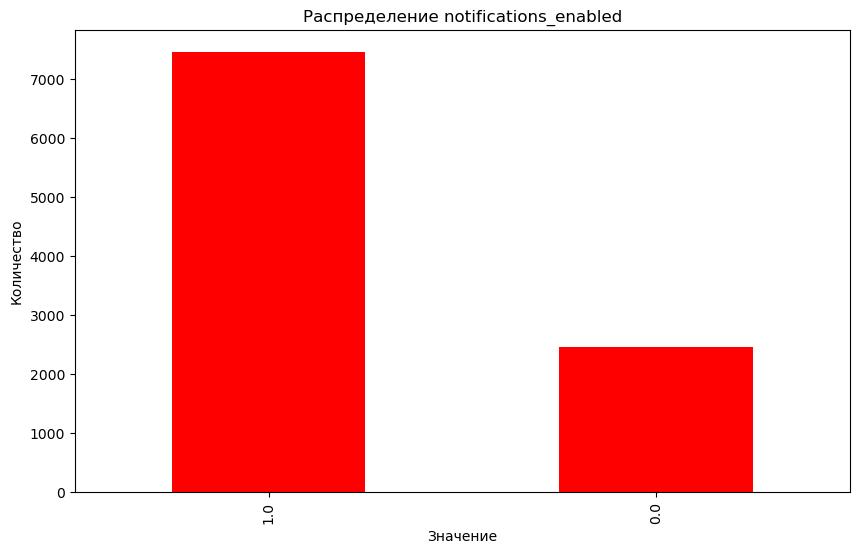

In [15]:
df_new['notifications_enabled'].value_counts().plot(kind='bar', figsize=(10,6), color='red') 
plt.title('Распределение notifications_enabled') 
plt.xlabel('Значение') 
plt.ylabel('Количество') 
plt.show()

In [16]:
seasonal_menu_tried = df_new['seasonal_menu_tried'].value_counts().sort_values(ascending=False)
seasonal_menu_tried

seasonal_menu_tried
1.0    6634
0.0    2827
Name: count, dtype: int64

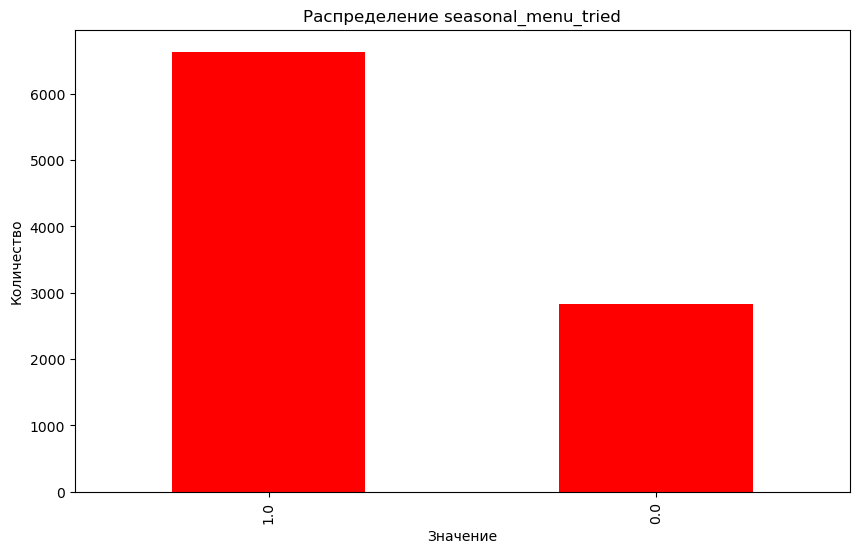

In [17]:
df_new['seasonal_menu_tried'].value_counts().plot(kind='bar', figsize=(10,6), color='red') 
plt.title('Распределение seasonal_menu_tried') 
plt.xlabel('Значение') 
plt.ylabel('Количество') 
plt.show()

In [18]:
preferred_roast = df_new['preferred_roast'].value_counts().sort_values(ascending=False)
preferred_roast

preferred_roast
medium    3458
light     3453
dark      3423
Name: count, dtype: int64

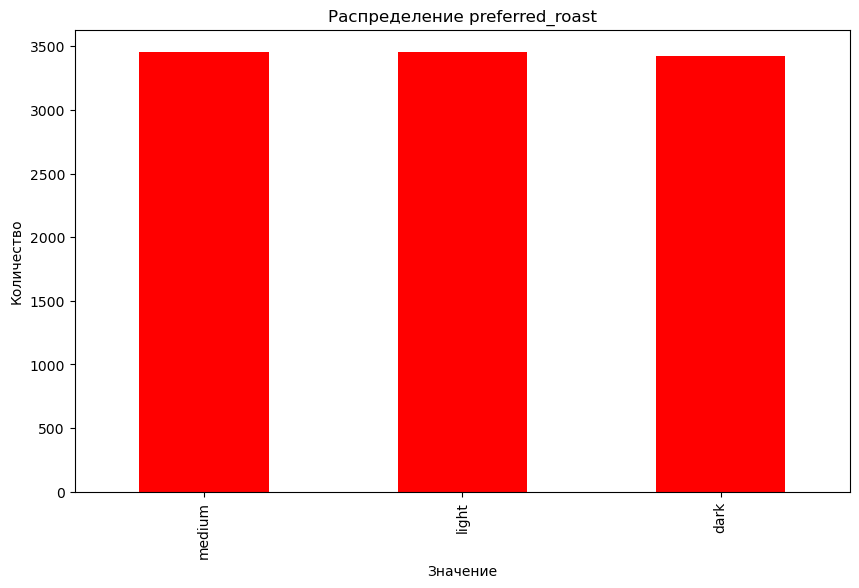

In [19]:
df_new['preferred_roast'].value_counts().plot(kind='bar', figsize=(10,6), color='red') 
plt.title('Распределение preferred_roast') 
plt.xlabel('Значение') 
plt.ylabel('Количество') 
plt.show()

In [20]:
drink_size = df_new['last_drink_size'].value_counts().sort_values(ascending=False)
drink_size

last_drink_size
medium    4925
large     2997
small     2024
Name: count, dtype: int64

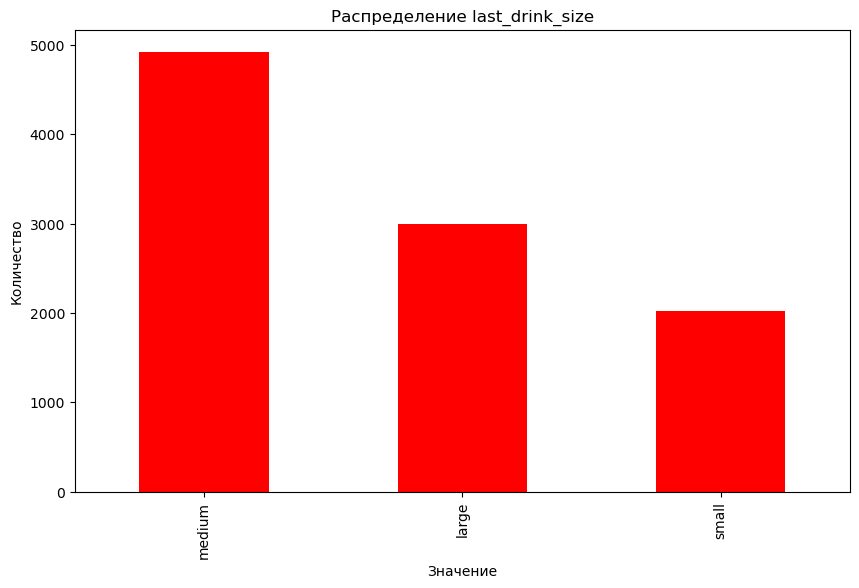

In [21]:
df_new['last_drink_size'].value_counts().plot(kind='bar', figsize=(10,6), color='red') 
plt.title('Распределение last_drink_size') 
plt.xlabel('Значение') 
plt.ylabel('Количество') 
plt.show()

In [22]:
milk = df_new['milk_preference'].value_counts().sort_values(ascending=False)
milk

milk_preference
whole     2876
oat       1982
almond    1483
skim      1451
none      1015
soy        975
Name: count, dtype: int64

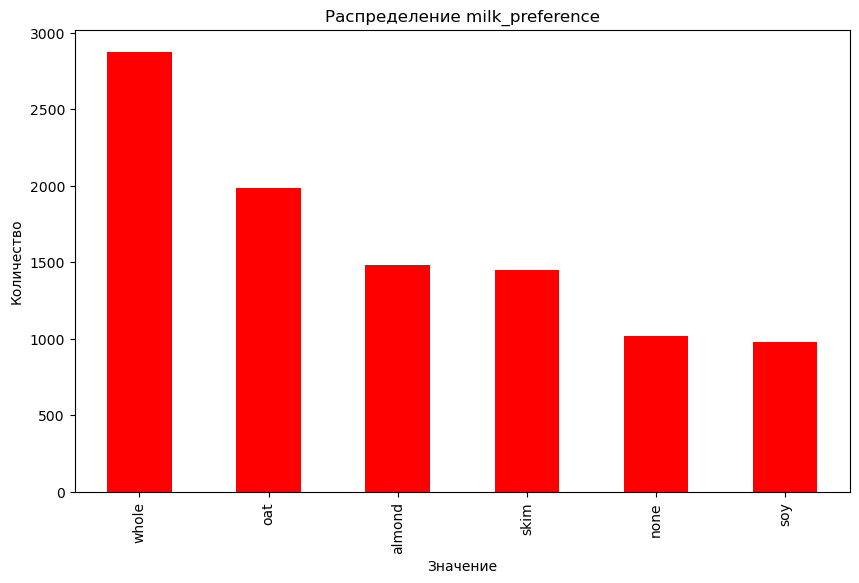

In [23]:
df_new['milk_preference'].value_counts().plot(kind='bar', figsize=(10,6), color='red') 
plt.title('Распределение milk_preference') 
plt.xlabel('Значение') 
plt.ylabel('Количество') 
plt.show()

In [24]:
seasons = df_new['seasons'].value_counts().sort_values(ascending=False)
seasons

seasons
spring    2507
autumn    2433
winter    2423
summer    2408
Name: count, dtype: int64

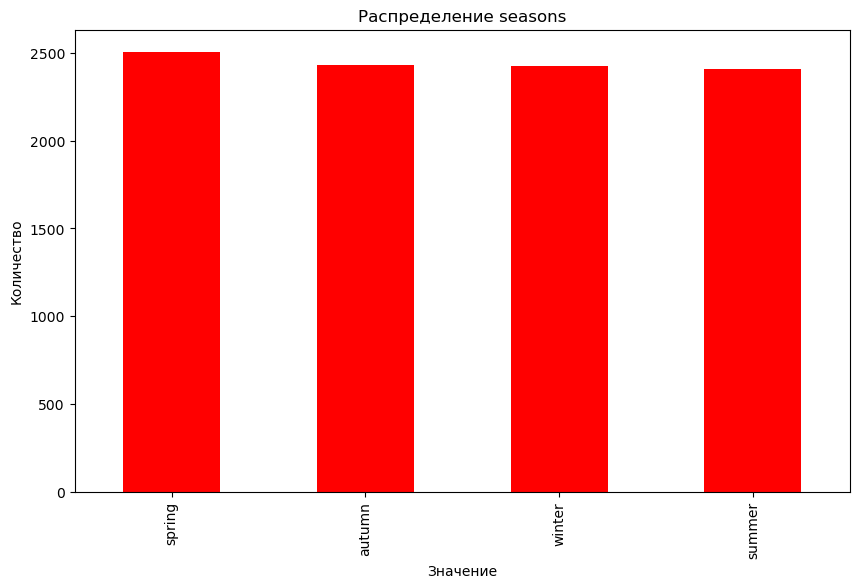

In [25]:
df_new['seasons'].value_counts().plot(kind='bar', figsize=(10,6), color='red') 
plt.title('Распределение seasons') 
plt.xlabel('Значение') 
plt.ylabel('Количество') 
plt.show()

In [26]:
been_cof = df_new['coffee_bean_origin'].value_counts().sort_values(ascending=False)
been_cof

coffee_bean_origin
ethiopia     1690
kenya        1646
vietnam      1635
guatemala    1621
brazil       1596
colombia     1580
Name: count, dtype: int64

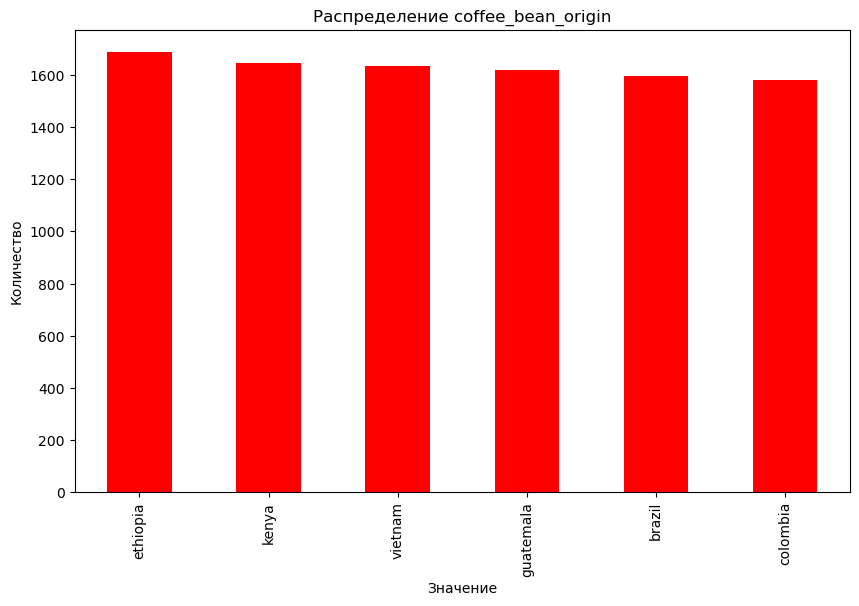

In [27]:
df_new['coffee_bean_origin'].value_counts().plot(kind='bar', figsize=(10,6), color='red') 
plt.title('Распределение coffee_bean_origin') 
plt.xlabel('Значение') 
plt.ylabel('Количество') 
plt.show()

In [28]:
type_cof = df_new['last_coffee_type'].value_counts().sort_values(ascending=False)
type_cof

last_coffee_type
arabica    6134
robusta    2524
blend      1534
Name: count, dtype: int64

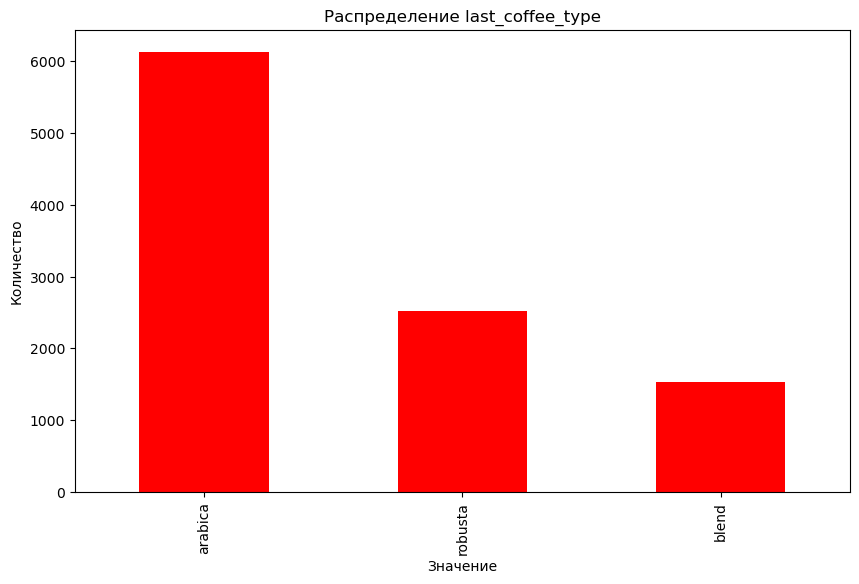

In [29]:
df_new['last_coffee_type'].value_counts().plot(kind='bar', figsize=(10,6), color='red') 
plt.title('Распределение last_coffee_type') 
plt.xlabel('Значение') 
plt.ylabel('Количество') 
plt.show()

In [30]:
geo = df_new['geo_location'].value_counts().sort_values(ascending=False)
geo

geo_location
geo_2     1629
geo_3     1573
geo_1     1532
geo_99     117
geo_95     110
          ... 
geo_41      42
geo_55      41
geo_45      41
geo_60      40
geo_86      38
Name: count, Length: 100, dtype: int64

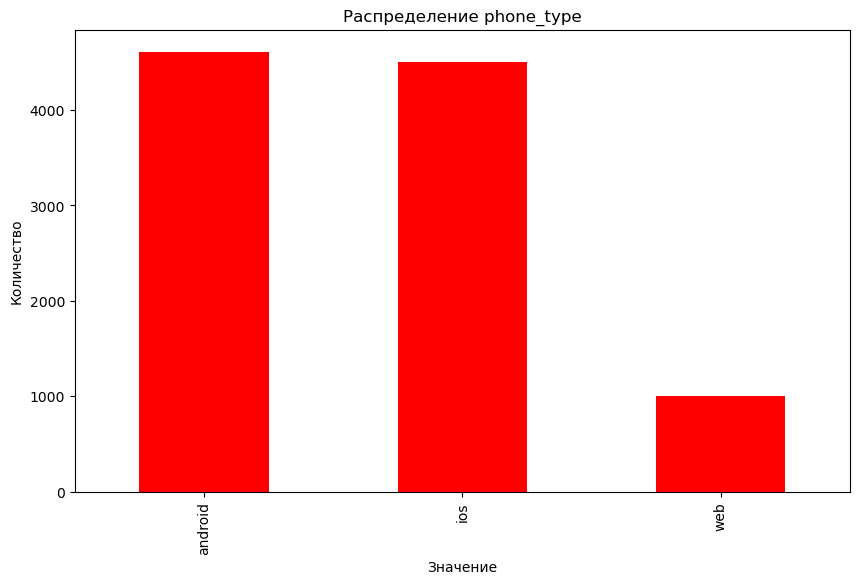

In [31]:
df_new['phone_type'].value_counts().plot(kind='bar', figsize=(10,6), color='red') 
plt.title('Распределение phone_type') 
plt.xlabel('Значение') 
plt.ylabel('Количество') 
plt.show()

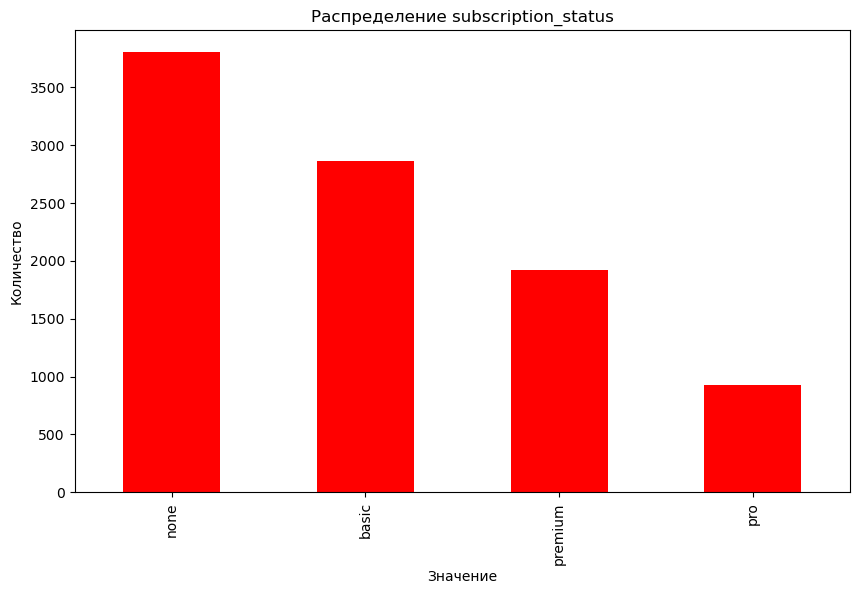

In [32]:
df_new['subscription_status'].value_counts().plot(kind='bar', figsize=(10,6), color='red') 
plt.title('Распределение subscription_status') 
plt.xlabel('Значение') 
plt.ylabel('Количество') 
plt.show()

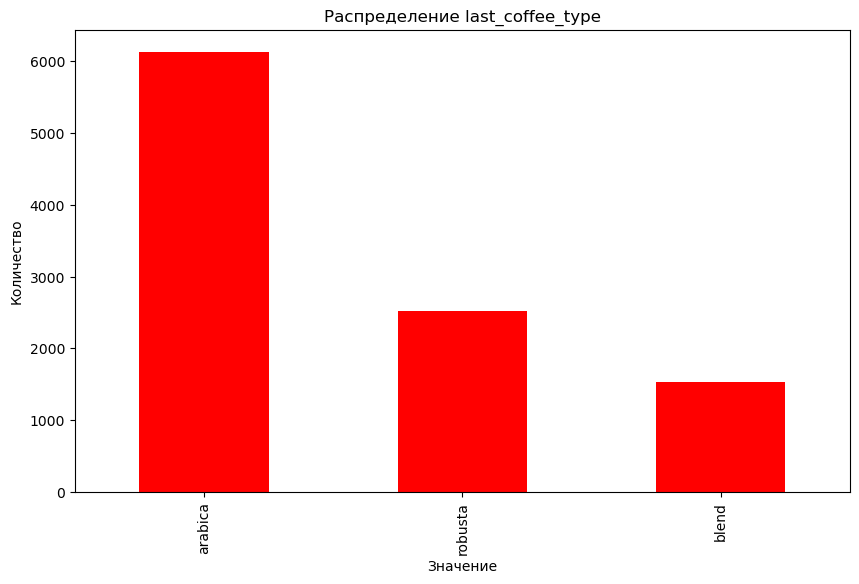

In [33]:
df_new['last_coffee_type'].value_counts().plot(kind='bar', figsize=(10,6), color='red') 
plt.title('Распределение last_coffee_type') 
plt.xlabel('Значение') 
plt.ylabel('Количество') 
plt.show()

Можно заметить, что переменные распределены неравномерно, поэтому вдальнейшем можно будет создать новые признаки, расчитав по ним квадратный корень, чтобы немного сгладить распределение

Теперь проверим выбросы в данных


In [34]:
df_new['days_since_last_promo'].describe()

count    9719.000000
mean       14.554584
std        15.308869
min         0.000000
25%         4.000000
50%        10.000000
75%        20.000000
max       140.000000
Name: days_since_last_promo, dtype: float64

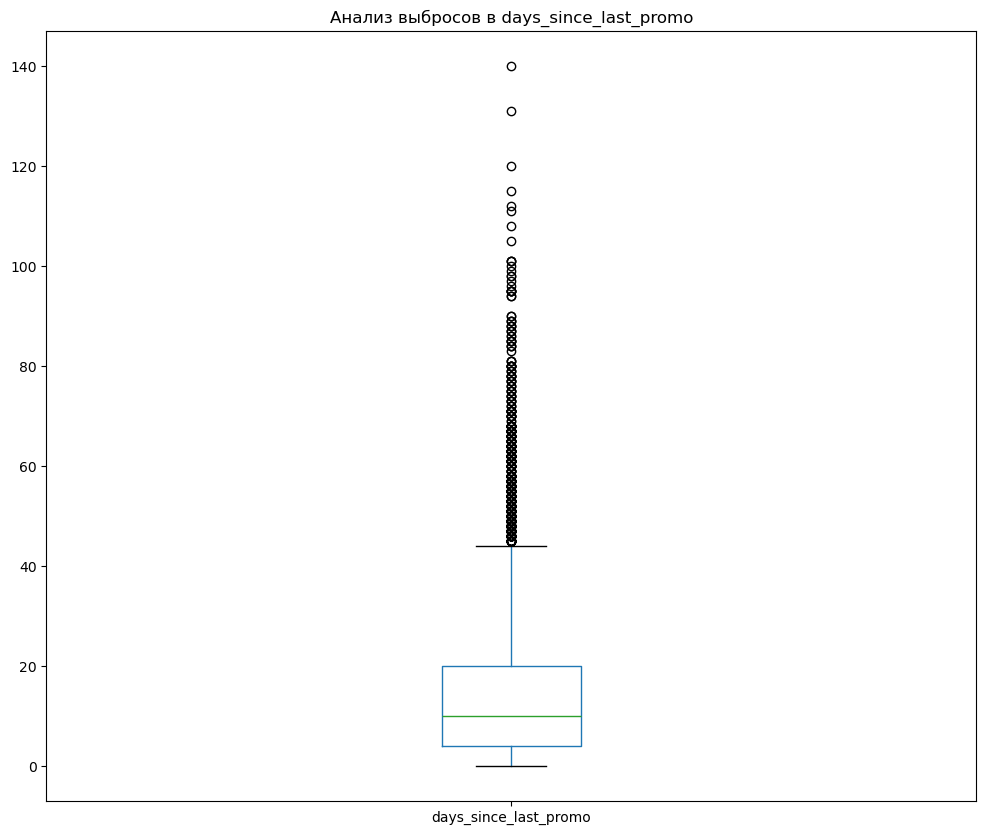

In [35]:
df_new.boxplot(column='days_since_last_promo', grid=False, figsize=(12,10))
plt.title('Анализ выбросов в days_since_last_promo')
plt.show()

В данных есть выбросы, но выбросы в большую сторону вполне возможны - их стоит оставить

In [36]:
df_new['days_since_last_order'].describe()

count    9505.000000
mean        4.394214
std         4.858757
min         0.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        40.000000
Name: days_since_last_order, dtype: float64

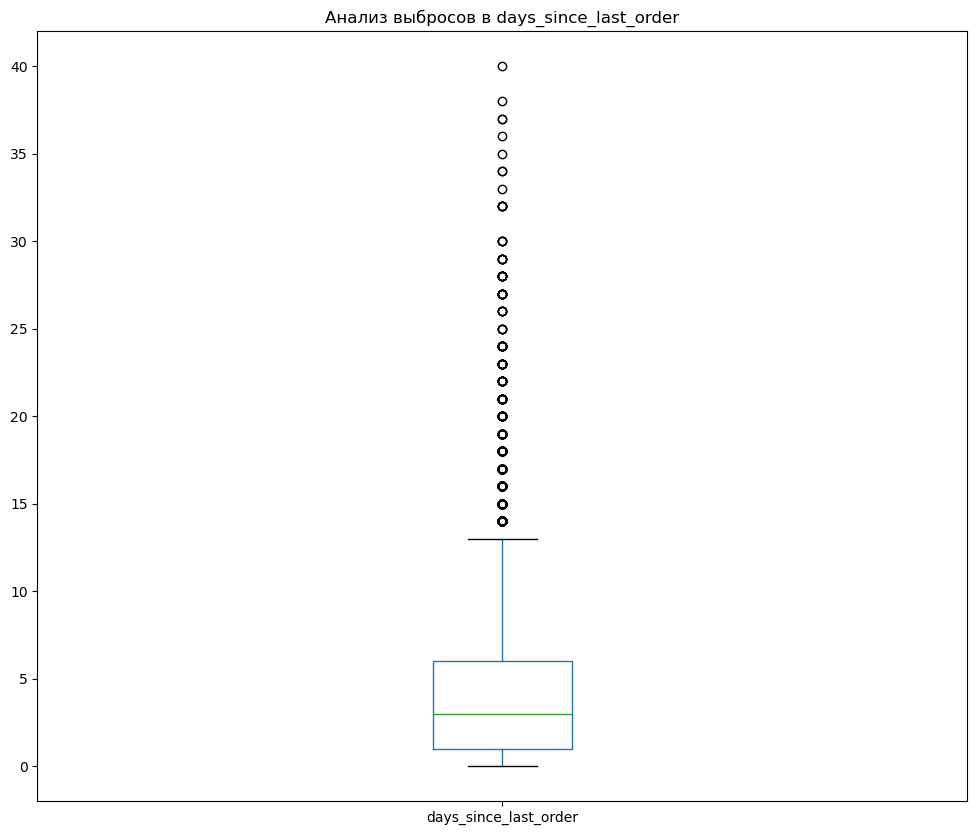

In [37]:
df_new.boxplot(column='days_since_last_order', grid=False, figsize=(12,10))
plt.title('Анализ выбросов в days_since_last_order')
plt.show()

В данных есть выбросы, но выбросы в большую сторону вполне возможны - их стоит оставить

In [38]:
df_new['order_frequency_week'].describe()

count    10062.000000
mean         0.930686
std          0.657261
min         -0.169131
25%          0.445185
50%          0.784839
75%          1.262350
max          6.302624
Name: order_frequency_week, dtype: float64

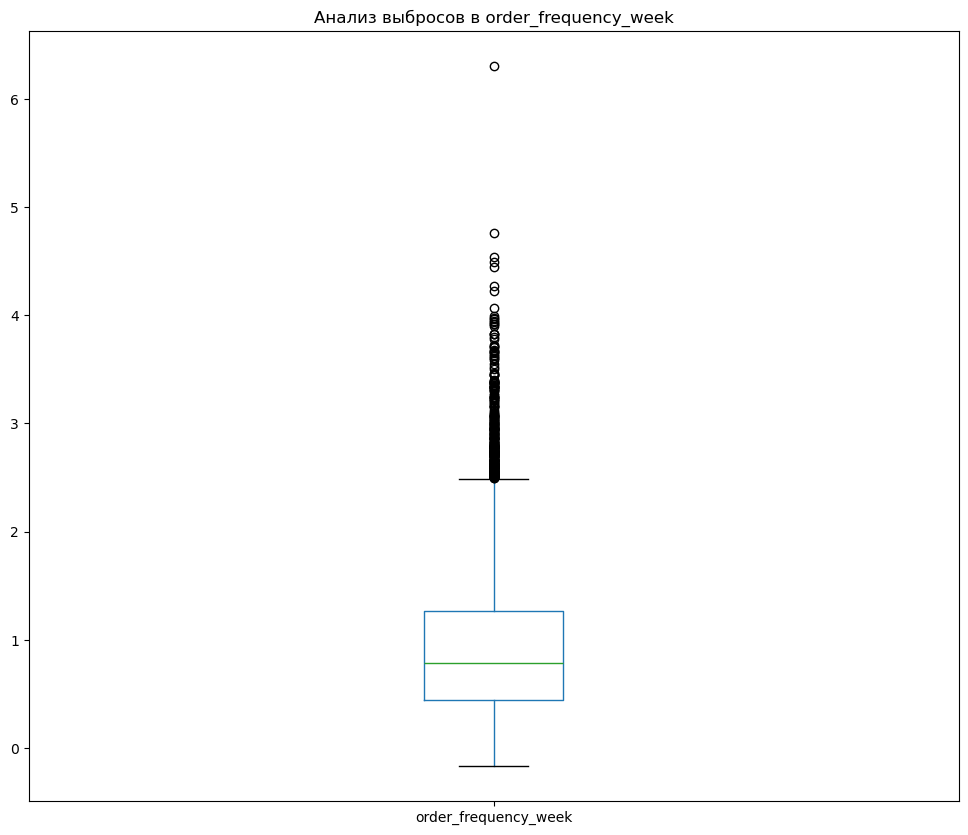

In [39]:
df_new.boxplot(column='order_frequency_week', grid=False, figsize=(12,10))
plt.title('Анализ выбросов в order_frequency_week')
plt.show()

Положительные выбросы в `order_frequency_week` нормальны и их стоит оставить, максимальный показатель по данномц столбцу - 6, значит, что кто-то сделала за неделю 6 заказов, что вполне веротяно. Но отрицательные значения аномальны, их стоит удалить

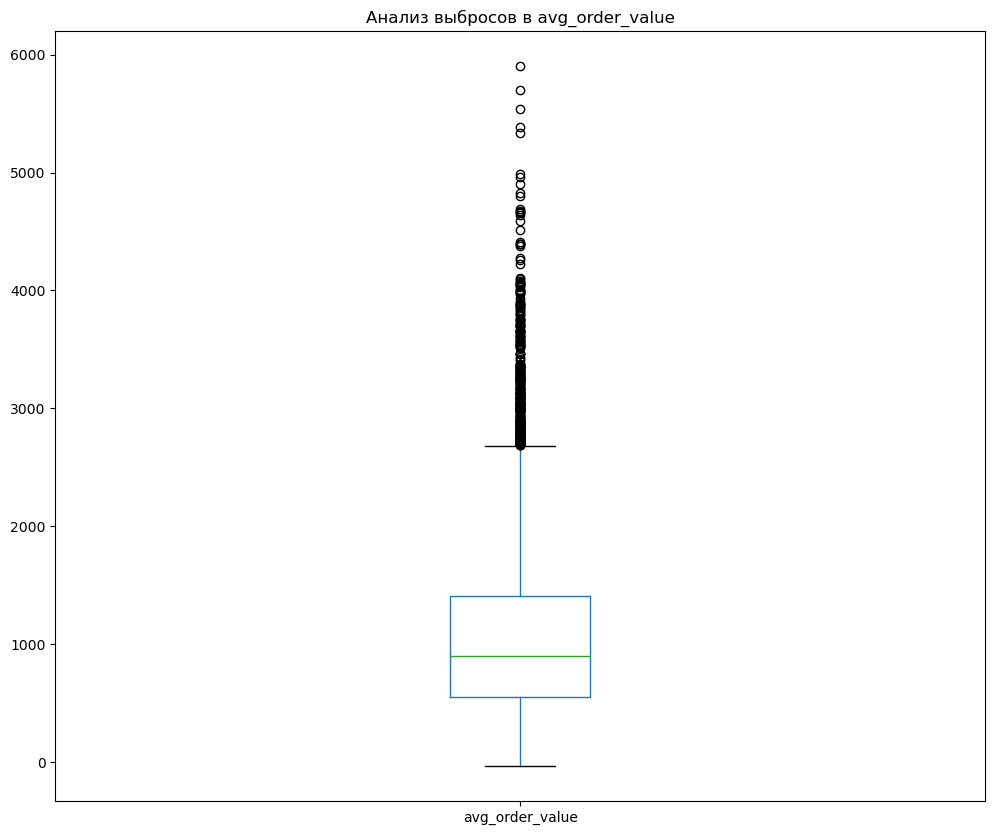

In [40]:
df_new.boxplot(column='avg_order_value', grid=False, figsize=(12,10))
plt.title('Анализ выбросов в avg_order_value')
plt.show()

В данных есть выбросы, но выбросы в большую сторону вполне возможны - их стоит оставить, но минимальное отрицательное значение аномально, его стоит удалить

Проверим выбросы в `total_spent_last_week`

In [41]:
df_new['total_spent_last_week'].describe()

count    9506.000000
mean      413.004760
std       445.634902
min     -2290.559468
25%       136.565833
50%       288.277327
75%       549.699420
max      8615.988952
Name: total_spent_last_week, dtype: float64

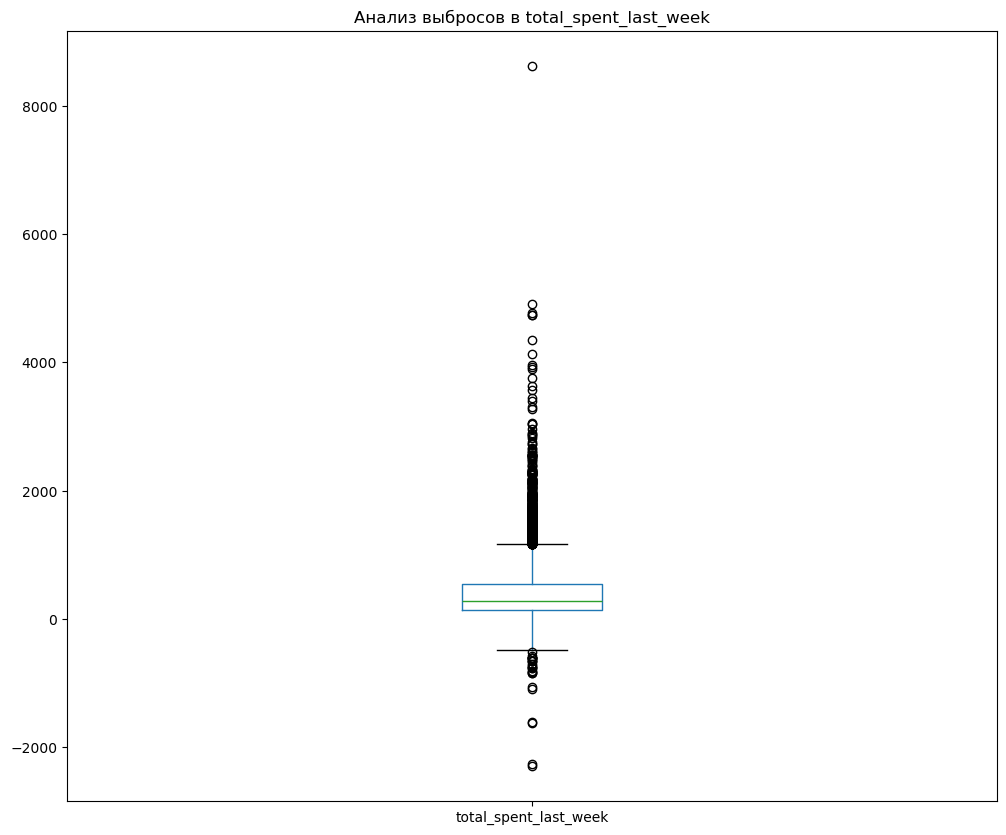

In [42]:
df_new.boxplot(column='total_spent_last_week', grid=False, figsize=(12,10))
plt.title('Анализ выбросов в total_spent_last_week')
plt.show()

In [43]:
minus_spent = df_new[(df_new['total_spent_last_week'] < 0)]
minus_spent

,days_since_last_order,order_frequency_week,avg_order_value,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,...,app_opens_per_week,notifications_enabled,review_rating_last_10,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
9,0.0,-0.094052,607.847810,-41.895977,NaN,blend,light,whole,NaN,guatemala,...,6.706418,1.0,4.362385,2.0,autumn,14.0,ios,0.0,geo_2,0
188,3.0,1.195954,1546.929497,-646.719093,0.055872,arabica,dark,none,NaN,kenya,...,18.613765,0.0,5.249486,1.0,winter,NaN,android,1.0,geo_36,0
191,2.0,-0.169131,3710.492841,-237.899451,0.115694,arabica,light,whole,1.0,ethiopia,...,5.022469,0.0,5.132989,2.0,winter,17.0,android,1.0,geo_15,0
193,24.0,0.567124,1342.726233,-344.924273,0.223425,NaN,light,none,1.0,kenya,...,12.251357,NaN,5.147882,2.0,autumn,6.0,android,1.0,geo_76,0
345,2.0,-0.074783,715.372314,-11.382833,0.365909,robusta,light,oat,1.0,ethiopia,...,5.045229,1.0,4.073474,2.0,summer,NaN,android,0.0,geo_21,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10003,5.0,0.830454,789.809037,-271.359227,0.330724,arabica,dark,none,NaN,guatemala,...,5.832262,1.0,5.042044,2.0,autumn,NaN,android,0.0,geo_3,0
10024,2.0,NaN,2359.212558,-755.346750,0.373559,arabica,dark,almond,1.0,ethiopia,...,8.043719,1.0,3.907031,4.0,winter,NaN,ios,1.0,geo_1,1
10025,3.0,0.444744,2719.829894,-334.023706,0.420309,robusta,medium,skim,1.0,guatemala,...,0.000000,0.0,5.767336,1.0,autumn,7.0,android,0.0,geo_3,0
10248,5.0,0.380135,2496.586366,-275.571784,0.359006,blend,medium,skim,1.0,ethiopia,...,3.071664,0.0,3.144985,2.0,autumn,34.0,ios,0.0,geo_2,0


Большие положительные значения возможны, а значения меньше нуля - аномальны, их стоит удалить

Проверим выбросы в `discount_usage_rate`


In [44]:
df_new['discount_usage_rate'].describe()

count    10053.000000
mean         0.284446
std          0.158735
min          0.002162
25%          0.159884
50%          0.264583
75%          0.387056
max          0.887301
Name: discount_usage_rate, dtype: float64

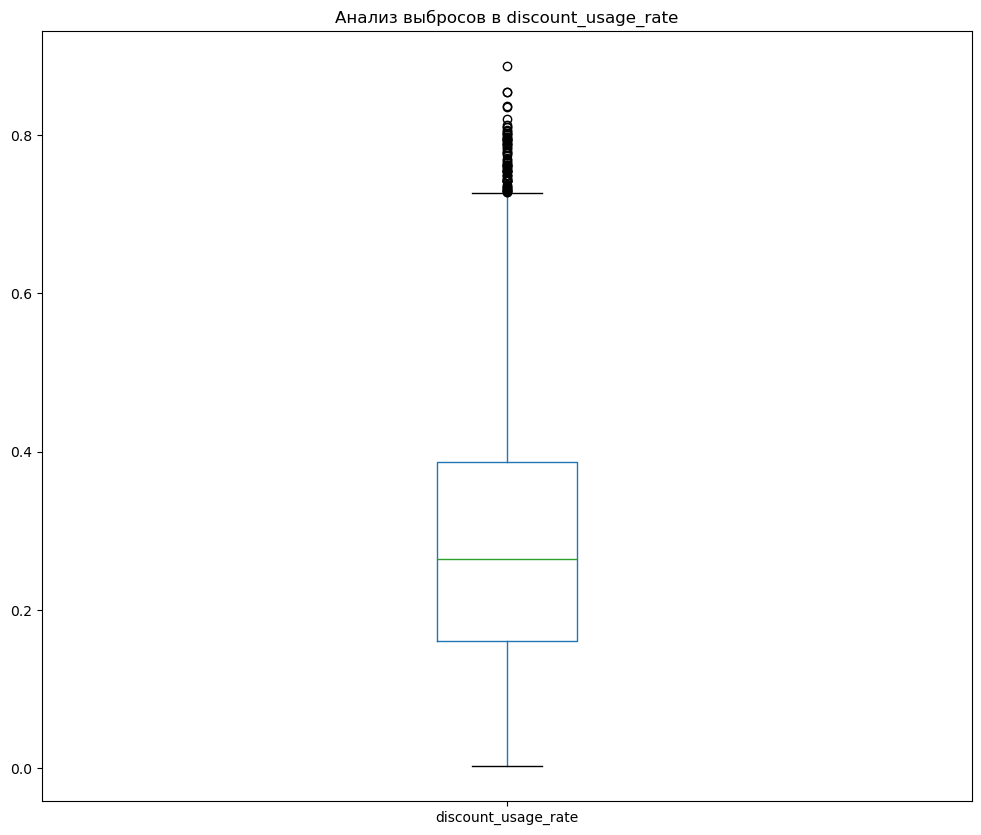

In [45]:
df_new.boxplot(column='discount_usage_rate', grid=False, figsize=(12,10))
plt.title('Анализ выбросов в discount_usage_rate')
plt.show()

В данных есть выбросы, но они возможны. Аномальные значения отсутствуют


Проверим выбросы в `app_opens_per_week`

In [46]:
df_new['app_opens_per_week'].describe()

count    9554.000000
mean       11.330895
std        14.528887
min         0.000000
25%         6.313628
50%         9.228383
75%        12.726649
max       224.587876
Name: app_opens_per_week, dtype: float64

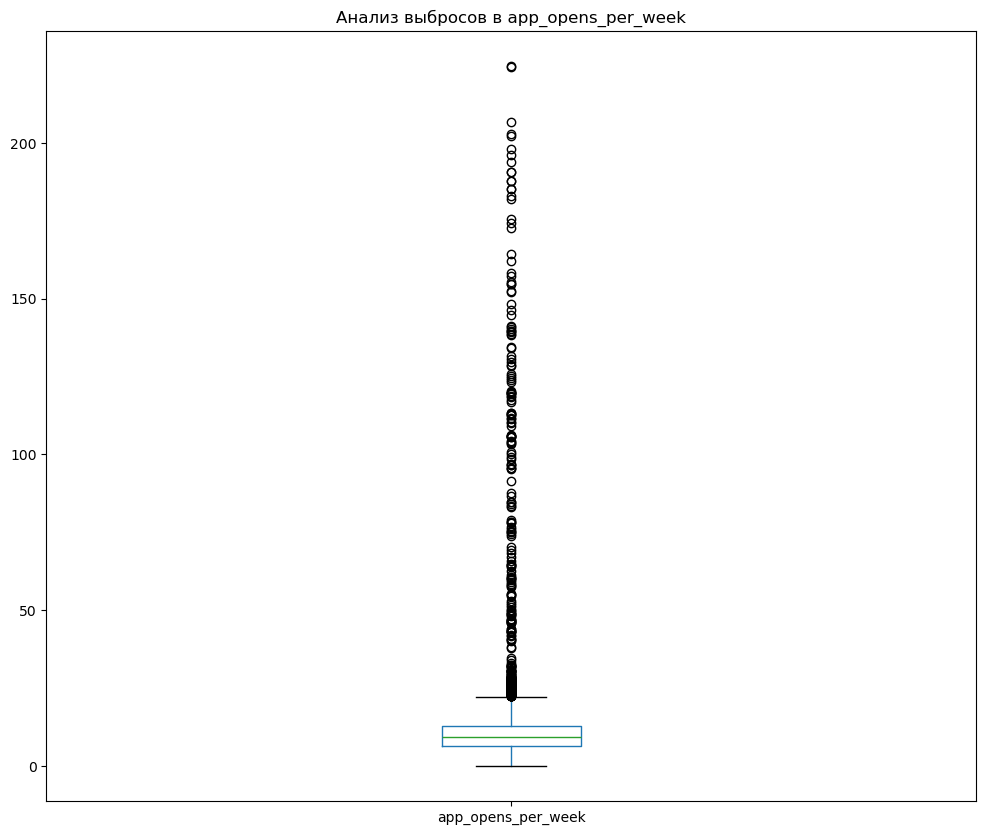

In [47]:
df_new.boxplot(column='app_opens_per_week', grid=False, figsize=(12,10))
plt.title('Анализ выбросов в app_opens_per_week')
plt.show()

В данных есть положительные выбросы, но аномальных значений нет


Проверим выбросы в `review_rating_last_10`

In [48]:
df_new['review_rating_last_10'].describe()

count    9757.000000
mean        4.206709
std         0.782212
min         1.415526
25%         3.675543
50%         4.203555
75%         4.717292
max         7.384425
Name: review_rating_last_10, dtype: float64

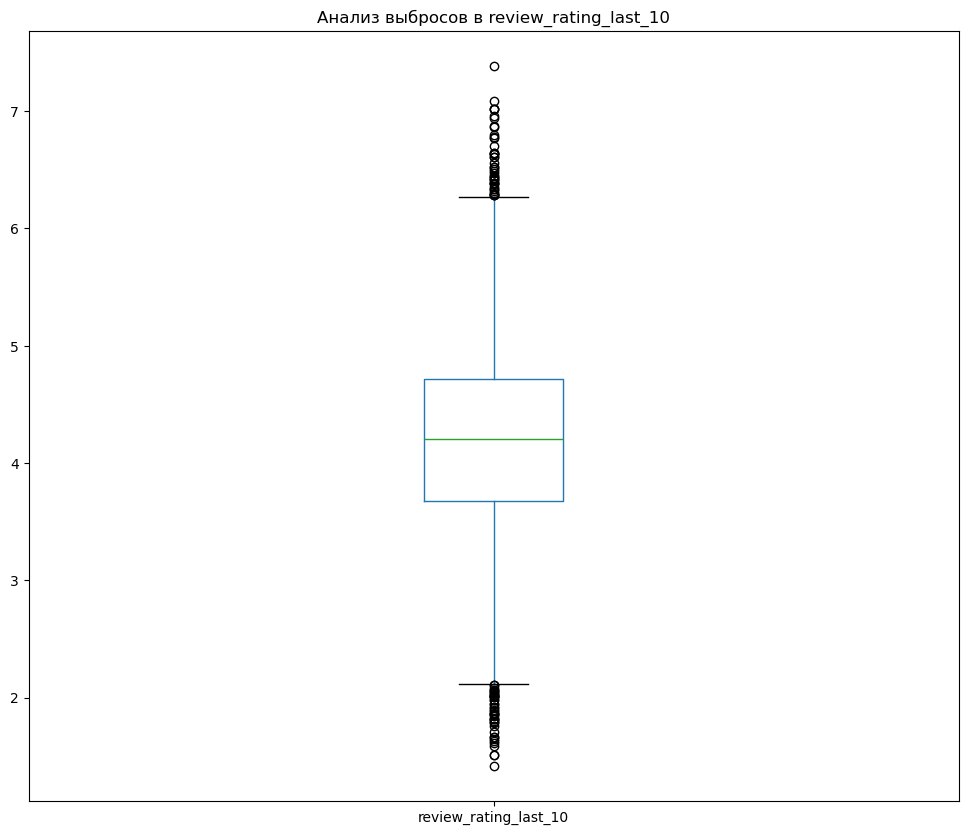

In [49]:
df_new.boxplot(column='review_rating_last_10', grid=False, figsize=(12,10))
plt.title('Анализ выбросов в review_rating_last_10')
plt.show()

В данных есть выбросы, но они возможны. Аномальные значения отсутствуют



Проверим выбросы в `app_crashes_last_month`


In [50]:
df_new['app_crashes_last_month'].describe()

count    9729.000000
mean        1.013362
std         1.010342
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: app_crashes_last_month, dtype: float64

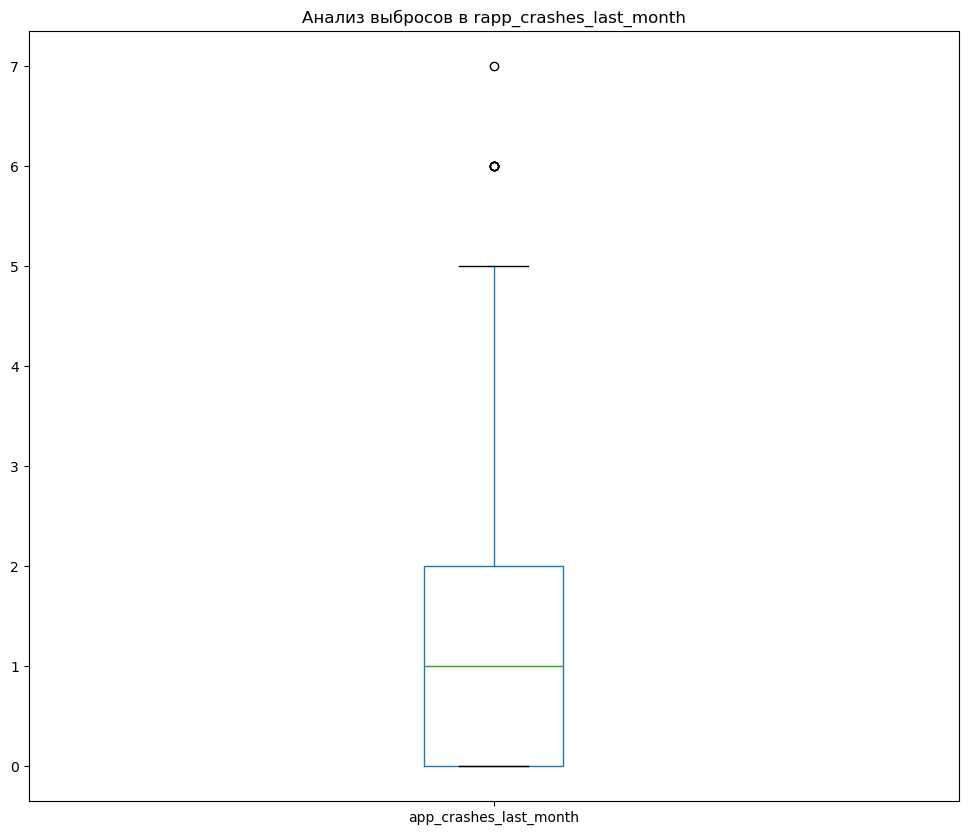

In [51]:
df_new.boxplot(column='app_crashes_last_month', grid=False, figsize=(12,10))
plt.title('Анализ выбросов в rapp_crashes_last_month')
plt.show()

В данных есть положительные выбросы, но аномальных значений нет

Проверим корреляцию признаков

In [52]:
cat_col2 = []
continuous_cols2 = []
for i in df_new.columns:
    if df_new[i].dtype == 'object':
        cat_col2.append(i)
    else:
        continuous_cols2.append(i)
df_subset2 = df_new[cat_col2 + continuous_cols2]
corr_matrix2 = phik_matrix(df_subset2, continuous_cols2)
corr_matrix2

,last_coffee_type,preferred_roast,milk_preference,coffee_bean_origin,last_drink_size,subscription_status,seasons,phone_type,geo_location,days_since_last_order,...,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
last_coffee_type,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005376,0.000000,0.024801,0.000000,...,0.013742,0.000000,0.000000,0.010053,0.009019,0.039906,0.044643,0.040072,0.000000,0.004434
preferred_roast,0.000000,1.000000,0.000000,0.021292,0.000000,0.000000,0.000000,0.072438,0.078271,0.034494,...,0.000000,0.000000,0.000000,0.031336,0.009243,0.041330,0.012704,0.000000,0.000000,0.000000
milk_preference,0.000000,0.000000,1.000000,0.000000,0.031805,0.000000,0.032692,0.044410,0.027525,0.023271,...,0.000000,0.038955,0.000000,0.025031,0.020933,0.043956,0.029884,0.032792,0.000000,0.000000
coffee_bean_origin,0.000000,0.021292,0.000000,1.000000,0.060043,0.014768,0.000000,0.000000,0.110375,0.000000,...,0.029290,0.000000,0.029428,0.000000,0.000000,0.020057,0.000000,0.000000,0.037478,0.000000
last_drink_size,0.000000,0.000000,0.031805,0.060043,1.000000,0.000000,0.004745,0.029179,0.045460,0.008871,...,0.029070,0.000000,0.000000,0.029857,0.000000,0.058226,0.000000,0.000000,0.005954,0.000000
subscription_status,0.000000,0.000000,0.000000,0.014768,0.000000,1.000000,0.016447,0.000000,0.039416,0.000000,...,0.026496,0.025947,0.010219,0.213973,0.000000,0.039324,0.000000,0.000000,0.000000,0.105164
seasons,0.005376,0.000000,0.032692,0.000000,0.004745,0.016447,1.000000,0.000000,0.071971,0.000000,...,0.026038,0.026710,0.000000,0.007008,0.015257,0.000000,0.000000,0.000000,0.000000,0.000000
phone_type,0.000000,0.072438,0.044410,0.000000,0.029179,0.000000,0.000000,1.000000,0.073889,0.020274,...,0.000000,0.000000,0.000000,0.000000,0.004037,0.035928,0.004908,0.025243,0.005718,0.005039
geo_location,0.024801,0.078271,0.027525,0.110375,0.045460,0.039416,0.071971,0.073889,1.000000,0.129053,...,0.048666,0.114433,0.000000,0.102501,0.000000,0.094371,0.170285,0.000000,0.027776,0.038881
days_since_last_order,0.000000,0.034494,0.023271,0.000000,0.008871,0.000000,0.000000,0.020274,0.129053,1.000000,...,0.000000,0.000000,0.043539,0.000000,0.026565,0.027785,0.000000,0.000000,0.022482,0.000000


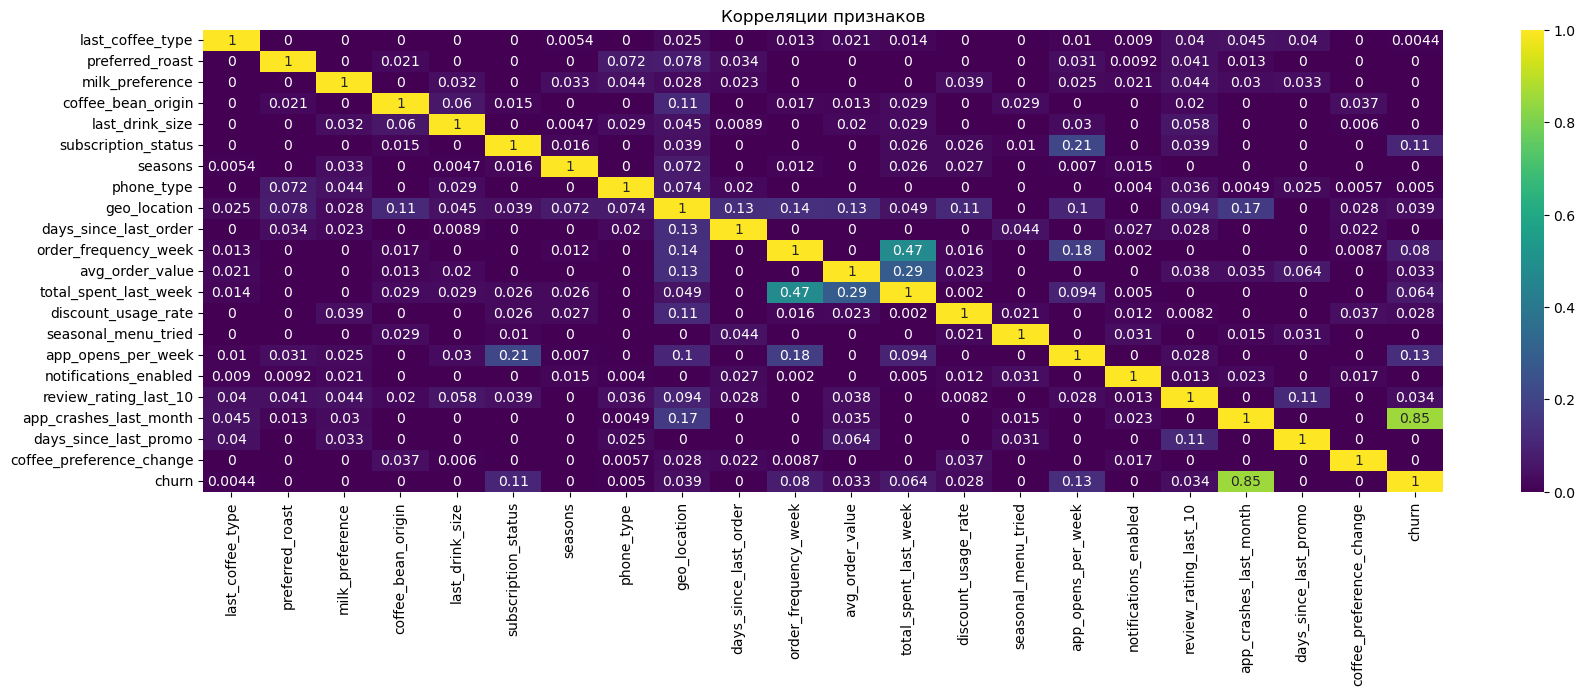

In [53]:
plt.figure(figsize=(20,6))
sns.heatmap(corr_matrix2, annot=True, cmap='viridis') 
plt.title('Корреляции признаков') 
plt.show()

В датасете есть признаков, которые бы вообще не коррелировали бы с другими признаками, на них стоит обратить внимание

**Выводы**

- Были удалены столбцы: `user_id, median_order_value, order_frequency_month, total_spent_last_month, review_rating_last_1`
- Было выявлено много пропусков
- Были выявлены аномальные значения в `avg_order_value, total_spent_last_week`


## Этап 3. Предобработка данных

Разделим данные на признаки и целевую переменную

In [54]:
X = df_new.drop('churn', axis=1)
y = df_new['churn']

Разделим данные в пропорции 80 к 20

In [55]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = 0.2, shuffle=True, stratify=y, random_state=RANDOM_STATE)
X_train_val.shape, X_test.shape, y_train_val.shape, y_test.shape

((8360, 21), (2090, 21), (8360,), (2090,))

Создадим пайплайны и трансформер для обработки данных




In [56]:
cat_features = [
    'subscription_status', 'last_coffee_type', 'phone_type', 'geo_location',
    'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size',
    'seasons'
]

num_zero_features = [
    'app_opens_per_week', 'app_crashes_last_month', 'discount_usage_rate', 
    'days_since_last_promo', 'seasonal_menu_tried', 'notifications_enabled', 
    'coffee_preference_change'
]

num_median_features = [
    'total_spent_last_week', 'avg_order_value', 'order_frequency_week'
]

num_mean_features = [
    'days_since_last_order', 'review_rating_last_10'
]

num_pipeline_zero = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

num_pipeline_median = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

num_pipeline_mean = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num_zero', num_pipeline_zero, num_zero_features),
        ('num_median', num_pipeline_median, num_median_features),
        ('num_mean', num_pipeline_mean, num_mean_features),
        ('cat', cat_pipeline, cat_features)
    ],
    verbose_feature_names_out=False,
    remainder='drop'
)


## Этап 4. Обучение модели



Обучим модель и посчитаем метрики

In [57]:
from sklearn.dummy import DummyClassifier

dummy_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))
])


NFold = 5
kfold = StratifiedKFold(n_splits=NFold, shuffle=True, random_state=RANDOM_STATE)

dummy_results = cross_validate(
    estimator=dummy_pipeline,
    X=X_train_val,
    y=y_train_val,
    scoring=['neg_log_loss', 'average_precision', 'precision', 'recall'],
    cv=kfold,
    return_train_score=True,
    n_jobs=-1
)

display(f"average_precision: {dummy_results['test_average_precision'].mean()}")
display(f"log_loss: {-dummy_results['test_neg_log_loss'].mean()}")
display(f"precision: {dummy_results['test_precision'].mean()}")
display(f"recall: {dummy_results['test_recall'].mean()}")

'average_precision: 0.06178404156205094'

'log_loss: 4.001017983863722'

'precision: 0.0707070707070707'

'recall: 0.06960396039603961'

Можно заметить, что модель очень плохо справляется с задачей


## Этап 5. Создание новых признаков


- В столбцах `app_opens_per_week, total_spent_last_week, avg_order_value` есть большие положительные выбросы, поэтому создадим признаки извлечением квадратного корня
- Столбец `app_crashes_last_month` возведем в квадрат, чтобы усилить его значения, так как он имеет наибольшую корреляцию с целевой переменной

In [58]:
X_train_val_new = X_train_val.copy()
X_train_val_new['app_opens_per_week_sqrt'] = np.sqrt(X_train_val_new['app_opens_per_week'])
X_train_val_new['total_spent_last_week_sqrt'] = np.sqrt(X_train_val_new['total_spent_last_week'])
X_train_val_new['avg_order_value_sqrt'] = np.sqrt(X_train_val_new['avg_order_value'])
X_train_val_new['app_crashes_last_month2'] = X_train_val_new['app_crashes_last_month']**2

C:\Users\OC\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\OC\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Удалим исходные признаки кроме `app_crashes_last_month`, чтобы избежать мультиколлинеарности


In [59]:
X_train_val_new.drop(columns=['app_opens_per_week', 'total_spent_last_week', 'avg_order_value'], inplace = True)

Обучим модель и проверим метрики


In [60]:
cat_features = [
    'subscription_status', 'last_coffee_type', 'phone_type', 'geo_location',
    'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size',
    'seasons'
]

num_features = [
    'app_opens_per_week_sqrt', 'app_crashes_last_month', 'app_crashes_last_month2',
    'order_frequency_week', 'discount_usage_rate', 'total_spent_last_week_sqrt',
    'avg_order_value_sqrt', 'review_rating_last_10'
]

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='none')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    verbose_feature_names_out=False,
    remainder='drop'
)


model = LogisticRegression(random_state=RANDOM_STATE)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

results = cross_validate(
    estimator=final_pipeline,
    X=X_train_val_new,
    y=y_train_val,
    scoring=['neg_log_loss', 'average_precision', 'precision', 'recall'],
    cv=kfold,
    return_train_score=True,
    return_estimator=True,
    n_jobs=-1
)

display(f"average_precision: {results['test_average_precision'].mean()}")
display(f"log_loss: {-results['test_neg_log_loss'].mean()}")
display(f"precision: {results['test_precision'].mean()}")
display(f"recall: {results['test_recall'].mean()}")

'average_precision: 0.6828135945130198'

'log_loss: 0.1185800087472928'

'precision: 0.7743879863841291'

'recall: 0.4951485148514851'

Можно заметить, что метрики стали лучше. Новые признаки делают модель лучше. Проверим влияние признаков



In [61]:
trained_pipeline = results['estimator'][0]
feature_names = trained_pipeline.named_steps['preprocessor'].get_feature_names_out()

coefficients = trained_pipeline.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values(by='coefficient', key=abs, ascending=True)

coef_df

,feature,coefficient
51,geo_location_geo_37,0.000388
83,geo_location_geo_66,0.002309
49,geo_location_geo_35,0.009114
48,geo_location_geo_34,0.012753
121,preferred_roast_dark,-0.020588
...,...,...
73,geo_location_geo_57,-1.051122
44,geo_location_geo_30,1.087827
23,geo_location_geo_11,1.090023
47,geo_location_geo_33,1.388766


In [62]:
coef_df_filtered = coef_df[~coef_df['feature'].str.contains('geo_location', na=False)]
display(coef_df_filtered)

,feature,coefficient
121,preferred_roast_dark,-0.020588
4,discount_usage_rate,0.021546
140,last_drink_size_none,0.025625
132,coffee_bean_origin_colombia,-0.027976
15,last_coffee_type_robusta,0.036635
135,coffee_bean_origin_kenya,-0.037952
1,app_crashes_last_month,0.045514
125,milk_preference_almond,0.047024
6,avg_order_value_sqrt,-0.048905
138,last_drink_size_large,-0.060588


Удалим все признаки, которые имееют коэффициент меньше 0.01

In [63]:
features_to_remove = coef_df[abs(coef_df['coefficient']) < 0.01]['feature'].tolist()

X_train_val_new_clean = X_train_val_new.drop(columns=features_to_remove, errors='ignore')

Проверим метрики после удаления признаков

In [64]:
cat_features_clean = [f for f in cat_features if f in X_train_val_new.columns]
num_features_clean = [f for f in num_features if f in X_train_val_new.columns]

num_pipeline_clean = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline_clean = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='none')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_clean = ColumnTransformer(
    transformers=[
        ('num', num_pipeline_clean, num_features_clean),
        ('cat', cat_pipeline_clean, cat_features_clean)
    ],
    verbose_feature_names_out=False,
    remainder='drop'
)

model_clean = LogisticRegression(random_state=RANDOM_STATE)

final_pipeline_clean = Pipeline(steps=[
    ('preprocessor', preprocessor_clean),
    ('model', model_clean)
])

results = cross_validate(
    estimator=final_pipeline_clean,
    X=X_train_val_new_clean,
    y=y_train_val,
    scoring=['neg_log_loss', 'average_precision', 'precision', 'recall'],
    cv=kfold,
    return_train_score=True,
    return_estimator=True,
    n_jobs=-1
)

display(f"average_precision: {results['test_average_precision'].mean()}")
display(f"log_loss: {-results['test_neg_log_loss'].mean()}")
display(f"precision: {results['test_precision'].mean()}")
display(f"recall: {results['test_recall'].mean()}")

'average_precision: 0.6828135945130198'

'log_loss: 0.1185800087472928'

'precision: 0.7743879863841291'

'recall: 0.4951485148514851'

Можно заметить, что метрики не изменились, значит мы и правдв избавились от ненужных признаков, не удалив ничего важного


## Этап 6. Эксперименты с гиперпараметрами

Зададим модели различные c и penalty (также будет меняться алгоритм оптимизации в зависимост от типа регулязации)




In [65]:
optimal_combinations = [
    ('l2', 'lbfgs'), 
    ('l2', 'liblinear'),  
    ('l1', 'liblinear'),  
    ('l2', 'saga'),       
]

c_ex = [0.01, 0.1, 1, 10, 100]
metric_results = []

for penalty, solver in optimal_combinations:
    for c in c_ex:
        model3 = LogisticRegression(
            penalty=penalty, 
            solver=solver, 
            C=c,
            max_iter=1000,
            random_state=RANDOM_STATE
        ) 
        pipeline3 = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', model3)
        ])
        
        test_res = cross_validate(
            estimator=pipeline3,          
            X=X_train_val_new_clean,                        
            y=y_train_val,                          
            scoring=['neg_log_loss', 'average_precision', 'precision', 'recall'],  
            cv=kfold,                        
            return_train_score=True,    
            return_estimator=True,      
            n_jobs=-1
        ) 
        
        cv_result = {
            'penalty': penalty,
            'solver': solver,
            'C': c,
            'PR_AUC': test_res['test_average_precision'].mean(),
            'log_loss': -test_res['test_neg_log_loss'].mean(),
            'precision': test_res['test_precision'].mean(),
            'recall': test_res['test_recall'].mean(),
        }
        metric_results.append(cv_result)

Соберем в таблицу результаты по метрикам и отстортируем по PR_AUC, так как данная метрика ключевая


In [66]:
test_result = pd.DataFrame(metric_results)
test_result.drop_duplicates(subset = ['PR_AUC', 'log_loss', 'precision', 'recall'], keep = 'first', inplace = True)

test_result.sort_values(['PR_AUC', 'penalty', 'solver', 'C'], ascending = False)

,penalty,solver,C,PR_AUC,log_loss,precision,recall
11,l1,liblinear,0.10,0.702611,0.114363,0.836799,0.457267
10,l1,liblinear,0.01,0.700365,0.130240,0.974075,0.286297
15,l2,saga,0.01,0.698741,0.117422,0.900887,0.365762
0,l2,lbfgs,0.01,0.698546,0.117420,0.900887,0.365762
5,l2,liblinear,0.01,0.697393,0.124026,0.905712,0.389644
6,l2,liblinear,0.10,0.694282,0.115350,0.799313,0.469287
16,l2,saga,0.10,0.694038,0.115269,0.796995,0.469267
1,l2,lbfgs,0.10,0.694021,0.115300,0.796662,0.469267
12,l1,liblinear,1.00,0.687897,0.117448,0.772477,0.481188
2,l2,lbfgs,1.00,0.682814,0.118580,0.774388,0.495149


Наилучшие результаты по PR_AUC показала модель с penalty-L1, solver-liblinear, c-0.1


## Этап 7. Подготовка финальной модели

Добавим в тестовую выборку новые признаки и удалим ненужные

In [67]:
X_test_new = X_test.copy()
X_test_new['app_opens_per_week_sqrt'] = np.sqrt(X_test_new['app_opens_per_week'])
X_test_new['total_spent_last_week_sqrt'] = np.sqrt(X_test_new['total_spent_last_week'])
X_test_new['avg_order_value_sqrt'] = np.sqrt(X_test_new['avg_order_value'])
X_test_new['app_crashes_last_month2'] = X_test_new['app_crashes_last_month']**2

C:\Users\OC\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [68]:
X_test_new.drop(columns=['app_opens_per_week', 'total_spent_last_week', 'avg_order_value'], inplace = True)
X_test_new.head(5)

,days_since_last_order,order_frequency_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,...,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,app_opens_per_week_sqrt,total_spent_last_week_sqrt,avg_order_value_sqrt,app_crashes_last_month2
7375,4.0,0.611561,0.233268,arabica,light,oat,0.0,guatemala,small,none,...,1.0,spring,17.0,android,NaN,geo_3,2.905512,19.494156,31.483680,1.0
7057,NaN,0.612120,0.701319,arabica,light,almond,1.0,ethiopia,large,pro,...,2.0,autumn,18.0,android,1.0,geo_23,2.800604,14.252753,30.016822,4.0
9451,8.0,2.048284,0.390578,arabica,light,almond,NaN,kenya,medium,basic,...,1.0,spring,2.0,android,0.0,geo_67,3.175567,37.763869,32.196771,1.0
1576,9.0,0.617897,0.324821,blend,dark,whole,0.0,colombia,medium,NaN,...,0.0,spring,5.0,ios,0.0,geo_13,1.742139,13.723908,21.732035,0.0
6559,4.0,0.281928,0.575780,arabica,dark,skim,NaN,guatemala,large,basic,...,NaN,NaN,8.0,android,0.0,geo_2,2.586425,11.128576,NaN,NaN


In [69]:
features_to_remove = coef_df[abs(coef_df['coefficient']) < 0.01]['feature'].tolist()

X_test_new_clean = X_test_new.drop(columns=features_to_remove, errors='ignore')

Обучим модель с новыми признаками и выбранными гиперпараметрами

In [70]:
final_model = LogisticRegression(penalty = 'l1', solver = 'liblinear', C = 0.1)

pipeline_a = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', final_model)
])

pipeline_a.fit(X_train_val_new_clean, y_train_val)
y_pred = pipeline_a.predict(X_test_new_clean)
y_proba = pipeline_a.predict_proba(X_test_new_clean)[:, 1]

C:\Users\OC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\OC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## Этап 8. Отчёт о проделанной работе


Проанализируем метрики


In [71]:
display(f"PR_AUC: {average_precision_score(y_test, y_proba)}")
display(f"log_loss: {log_loss(y_test, y_proba)}")
display(f"precision: {precision_score(y_test, y_pred)}")
display(f"recall: {recall_score(y_test, y_pred)}")

'PR_AUC: 0.6881629610726129'

'log_loss: 0.11468603306075191'

'precision: 0.7402597402597403'

'recall: 0.4523809523809524'

На тестовой выборке модель показывает примерно такие же результаты, как и на обучающей. PR_AUC и log_loss немного улучшились, а precision и recall стали чуть хуже


Факторы повлиявшие на обучение модели:

- Предобработка данных, замена и удаление пропусков и обработка выбросов
- Использование кросс-валидации
- Добавление новых признаков
- Подбор гиперпараметров


## Этап 9. Сохранение модели для продакшена

In [72]:
joblib.dump(pipeline_a, 'Happy_Beans_Coffee_classifier.joblib')

loaded_model = joblib.load('Happy_Beans_Coffee_classifier.joblib')

y_pred = loaded_model.predict(X_test_new)
y_proba = loaded_model.predict_proba(X_test_new)[:, 1]

display(f"PR_AUC: {average_precision_score(y_test, y_proba)}")
display(f"log_loss: {log_loss(y_test, y_proba)}")
display(f"precision: {precision_score(y_test, y_pred)}")
display(f"recall: {recall_score(y_test, y_pred)}")

'PR_AUC: 0.6881629610726129'

'log_loss: 0.11468603306075191'

'precision: 0.7402597402597403'

'recall: 0.4523809523809524'

In [73]:
!pip install session_info


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
import session_info
session_info.show()

C:\Users\OC\anaconda3\Lib\site-packages\session_info\main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
